In [1]:
import numpy as np

X_train = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/training.npy')
y_train = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/training_labels.npy')
X_test = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/test.npy')
y_test = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/test_labels.npy')
embedding_matrix = np.load('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/embedding_matrix.npy')

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, Dense, Embedding, LSTM, Dropout, Conv1D
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

vocab_size = 52145

embedding = Embedding(vocab_size,
                      output_dim=int(3e2),
                      weights=[embedding_matrix],
                      trainable=True)

model = Sequential()
model.add(embedding)
model.add(Bidirectional(LSTM(256, return_sequences=True), input_shape=(X_train.shape[1],1)))#
model.add(Dropout(0.25))
model.add(Bidirectional(LSTM(128)))
# model.add(Dropout(0.3))
# model.add(Dense(32))
# model.add(Dropout(0.3))
# model.add(Dense(16))
model.add(Dropout(0.25))
model.add(Dense(128))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 300)         15643500  
                                                                 
 bidirectional (Bidirection  (None, None, 512)         1140736   
 al)                                                             
                                                                 
 dropout (Dropout)           (None, None, 512)         0         
                                                                 
 bidirectional_1 (Bidirecti  (None, 256)               656384    
 onal)                                                           
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense (Dense)               (None, 128)               3

In [3]:
history = model.fit(X_train, y_train,
                    batch_size=1024,
                    epochs=100,
                    verbose=1,
                    validation_split=0.1)


Epoch 1/100
22/22 [==============================] - 39s 1s/step - loss: 0.6983 - accuracy: 0.5004 - val_loss: 0.7185 - val_accuracy: 0.3664
Epoch 2/100
22/22 [==============================] - 29s 1s/step - loss: 0.6745 - accuracy: 0.5896 - val_loss: 0.7690 - val_accuracy: 0.1800
Epoch 3/100
22/22 [==============================] - 29s 1s/step - loss: 0.6598 - accuracy: 0.6135 - val_loss: 0.7699 - val_accuracy: 0.2324
Epoch 4/100
22/22 [==============================] - 28s 1s/step - loss: 0.6432 - accuracy: 0.6476 - val_loss: 0.7529 - val_accuracy: 0.3412
Epoch 5/100
22/22 [==============================] - 29s 1s/step - loss: 0.6263 - accuracy: 0.6772 - val_loss: 0.7280 - val_accuracy: 0.4488
Epoch 6/100
22/22 [==============================] - 28s 1s/step - loss: 0.6048 - accuracy: 0.7088 - val_loss: 0.6993 - val_accuracy: 0.5348
Epoch 7/100
22/22 [==============================] - 28s 1s/step - loss: 0.5806 - accuracy: 0.7306 - val_loss: 0.6611 - val_accuracy: 0.6212
Epoch 8/100
2

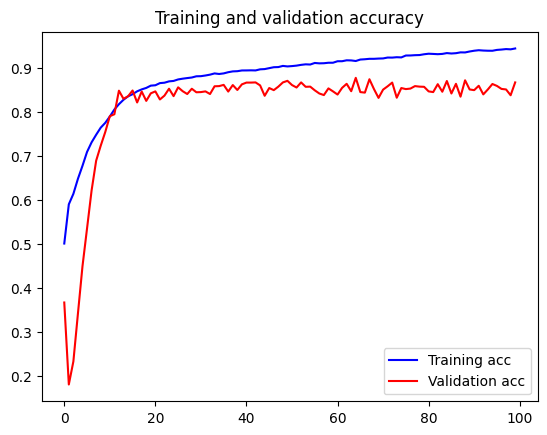

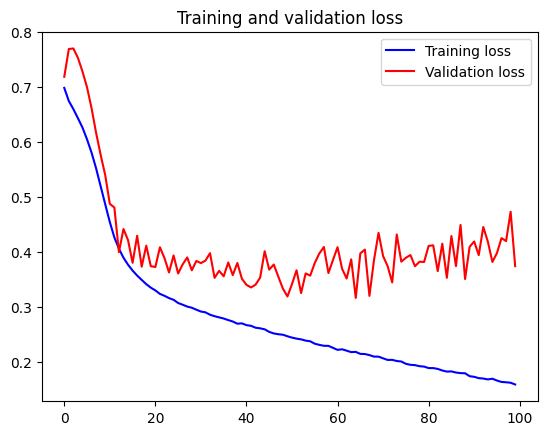

In [4]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [5]:
score = model.evaluate(X_test, y_test, batch_size=1024)
print()
print("ACCURACY:",score[1])
print("LOSS:",score[0])

25/25 [==============================] - 10s 398ms/step - loss: 0.3375 - accuracy: 0.8762

ACCURACY: 0.8761950731277466
LOSS: 0.3374931514263153


In [6]:
model.save('/content/drive/MyDrive/1. Natural Language Processsing/Khóa luận tốt nghiệp/Word2vec/English/model_BiLSTM.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
